Phase 0 :- IMPORTS, CONFIGURATION & FILE DISCOVERY

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
ROLLING_WINDOW = "10s"
STRICT_THRESHOLD = 0.90

# File discovery works locally, in the supplied execution environment,
# and after files are uploaded into Google Colab.
def find_csv(filename_keywords):
    candidates = []
    for root in [".", "/mnt/data"]:
        for pattern in [f"**/*{filename_keywords}*.csv"]:
            candidates.extend(glob.glob(os.path.join(root, pattern), recursive=True))
    # Prefer the shortest/most direct path if several copies exist.
    if not candidates:
        return None
    return sorted(set(candidates), key=lambda p: (len(p), p))[0]

VIDEO_PATH = find_csv("video_telemetry")
SYSTEM_PATH = find_csv("system_events")

# Google Colab fallback if files are not already present.
if VIDEO_PATH is None or SYSTEM_PATH is None:
    try:
        from google.colab import files
        print("Upload video_telemetry.csv and system_events.csv")
        uploaded = files.upload()
        VIDEO_PATH = VIDEO_PATH or find_csv("video_telemetry")
        SYSTEM_PATH = SYSTEM_PATH or find_csv("system_events")
    except ImportError:
        pass

if VIDEO_PATH is None or SYSTEM_PATH is None:
    raise FileNotFoundError(
        "Could not locate both CSV files. Place video_telemetry.csv and "
        "system_events.csv in the notebook folder or upload them in Colab."
    )

print("Video file :", VIDEO_PATH)
print("System file:", SYSTEM_PATH)


Upload video_telemetry.csv and system_events.csv


Saving video_telemetry (1) (1).csv to video_telemetry (1) (1) (2).csv
Saving system_events (1) (1).csv to system_events (1) (1).csv
Video file : ./video_telemetry (1) (1).csv
System file: ./system_events (1) (1).csv


Phase 1 — Data Ingestion & Asynchronous Temporal Alignment

In [ ]:

# ============================================================
# 1. LOAD AND VALIDATE THE TWO ASYNCHRONOUS DATASETS
# ============================================================
video_df = pd.read_csv(VIDEO_PATH)
sys_df = pd.read_csv(SYSTEM_PATH)

required_video = {"timestamp", "eye_gaze_angle", "audio_db"}
required_system = {"timestamp", "tab_switches", "is_cheating"}

missing_video = required_video - set(video_df.columns)
missing_system = required_system - set(sys_df.columns)

if missing_video:
    raise ValueError(f"Missing video columns: {sorted(missing_video)}")
if missing_system:
    raise ValueError(f"Missing system columns: {sorted(missing_system)}")

video_df["timestamp"] = pd.to_datetime(video_df["timestamp"], errors="coerce")
sys_df["timestamp"] = pd.to_datetime(sys_df["timestamp"], errors="coerce")

video_df = video_df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
sys_df = sys_df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print(f"Video telemetry shape : {video_df.shape}")
print(f"System events shape   : {sys_df.shape}")
print(f"Video time range      : {video_df['timestamp'].min()} → {video_df['timestamp'].max()}")
print(f"Event time range      : {sys_df['timestamp'].min()} → {sys_df['timestamp'].max()}")

# ============================================================
# ASYNCHRONOUS MERGE — NEAREST VIDEO SECOND
# ============================================================
merged_df = pd.merge_asof(
    video_df,
    sys_df[["timestamp", "tab_switches", "is_cheating"]],
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("500ms"),
)

print("\nMatched event rows before filling:")
print(merged_df[["tab_switches", "is_cheating"]].notna().sum())

display(merged_df.head())


Video telemetry shape : (10000, 3)
System events shape   : (167, 3)
Video time range      : 2023-12-01 08:00:00 → 2023-12-01 10:46:39
Event time range      : 2023-12-01 08:00:32.181296 → 2023-12-01 10:45:39.962066

Matched event rows before filling:
tab_switches    163
is_cheating     163
dtype: int64


,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,NaN,NaN
1,2023-12-01 08:00:01,10.177137,39.102627,NaN,NaN
2,2023-12-01 08:00:02,5.761714,31.228565,NaN,NaN
3,2023-12-01 08:00:03,9.787105,34.051405,NaN,NaN
4,2023-12-01 08:00:04,4.572665,35.245018,NaN,NaN


Phase 2 — Missing Data & Signal Processing

In [ ]:

# ============================================================
# 2. DATA CLEANING — PRESERVE THE EXAM TIMELINE
# ============================================================
before_missing = merged_df[["eye_gaze_angle", "audio_db"]].isna().sum()

# Eye gaze: carry the last valid sensor position forward.
merged_df["eye_gaze_angle"] = (
    merged_df["eye_gaze_angle"]
    .ffill()
    .bfill()
)

# Audio: interpolate mathematically across dropped frames.
merged_df["audio_db"] = (
    merged_df["audio_db"]
    .interpolate(method="linear")
    .ffill()
    .bfill()
)

# No event at a timestamp means zero event activity.
merged_df["tab_switches"] = merged_df["tab_switches"].fillna(0)
merged_df["is_cheating"] = merged_df["is_cheating"].fillna(0).astype(int)

after_missing = merged_df[["eye_gaze_angle", "audio_db"]].isna().sum()

print("Missing sensor values BEFORE cleaning:")
print(before_missing)
print("\nMissing sensor values AFTER cleaning:")
print(after_missing)

# ============================================================
# 10-SECOND ROLLING-WINDOW FEATURES
# ============================================================
merged_df = merged_df.sort_values("timestamp").set_index("timestamp")

# Rolling mean captures sustained gaze deviation.
merged_df["gaze_rolling_10s"] = (
    merged_df["eye_gaze_angle"]
    .rolling(ROLLING_WINDOW, min_periods=1)
    .mean()
)

# Rolling maximum captures sustained/high background audio activity.
merged_df["audio_rolling_10s"] = (
    merged_df["audio_db"]
    .rolling(ROLLING_WINDOW, min_periods=1)
    .max()
)

# Additional useful temporal features.
merged_df["gaze_abs_deviation"] = merged_df["eye_gaze_angle"].abs()
merged_df["gaze_change_10s"] = (
    merged_df["eye_gaze_angle"]
    .diff()
    .abs()
    .rolling(ROLLING_WINDOW, min_periods=1)
    .mean()
)

merged_df = merged_df.reset_index()

print("\nFeature engineering complete.")
print("Final timeline shape:", merged_df.shape)

display(
    merged_df[
        [
            "timestamp",
            "eye_gaze_angle",
            "audio_db",
            "tab_switches",
            "gaze_rolling_10s",
            "audio_rolling_10s",
            "is_cheating",
        ]
    ].head(12)
)


Missing sensor values BEFORE cleaning:
eye_gaze_angle    732
audio_db          732
dtype: int64

Missing sensor values AFTER cleaning:
eye_gaze_angle    0
audio_db          0
dtype: int64

Feature engineering complete.
Final timeline shape: (10000, 9)


,timestamp,eye_gaze_angle,audio_db,tab_switches,gaze_rolling_10s,audio_rolling_10s,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,0.0,2.560857,36.553781,0
1,2023-12-01 08:00:01,10.177137,39.102627,0.0,6.368997,39.102627,0
2,2023-12-01 08:00:02,5.761714,31.228565,0.0,6.166569,39.102627,0
3,2023-12-01 08:00:03,9.787105,34.051405,0.0,7.071703,39.102627,0
4,2023-12-01 08:00:04,4.572665,35.245018,0.0,6.571896,39.102627,0
5,2023-12-01 08:00:05,7.471741,43.685711,0.0,6.721870,43.685711,0
6,2023-12-01 08:00:06,7.148505,32.754163,0.0,6.782818,43.685711,0
7,2023-12-01 08:00:07,9.192380,43.786308,0.0,7.084013,43.786308,0
8,2023-12-01 08:00:08,4.223888,34.097144,0.0,6.766221,43.786308,0
9,2023-12-01 08:00:09,3.524030,39.177137,0.0,6.442002,43.786308,0


Phase 3 — Exploratory Checks

Target distribution:
  Not Cheating (0): 9,927 rows (99.27%)
  Cheating (1): 73 rows (0.73%)

Remaining missing values:
eye_gaze_angle       0
audio_db             0
tab_switches         0
gaze_rolling_10s     0
audio_rolling_10s    0
is_cheating          0
dtype: int64


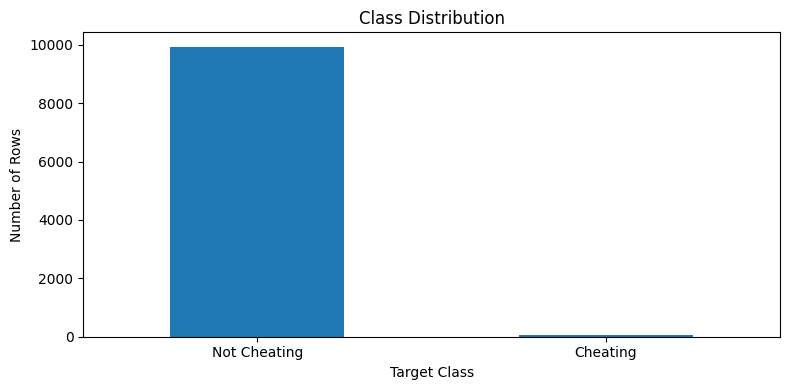

In [ ]:

# ============================================================
# 3. TARGET DISTRIBUTION & QUICK DATA QUALITY CHECK
# ============================================================
class_counts = merged_df["is_cheating"].value_counts().sort_index()
class_percent = merged_df["is_cheating"].value_counts(normalize=True).sort_index() * 100

print("Target distribution:")
for label in class_counts.index:
    name = "Not Cheating (0)" if label == 0 else "Cheating (1)"
    print(f"  {name}: {class_counts[label]:,} rows ({class_percent[label]:.2f}%)")

print("\nRemaining missing values:")
print(merged_df[
    ["eye_gaze_angle", "audio_db", "tab_switches",
     "gaze_rolling_10s", "audio_rolling_10s", "is_cheating"]
].isna().sum())

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Rows")
plt.xticks([0, 1], ["Not Cheating", "Cheating"], rotation=0)
plt.tight_layout()
plt.show()


Phase 4 — Class-Balanced Random Forest

In [ ]:

# ============================================================
# 4. MODEL TRAINING
# ============================================================
features = [
    "eye_gaze_angle",
    "audio_db",
    "tab_switches",
    "gaze_rolling_10s",
    "audio_rolling_10s",
    "gaze_abs_deviation",
    "gaze_change_10s",
]

X = merged_df[features].copy()
y = merged_df["is_cheating"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)

print("✅ Model training complete.")
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Positive class in training:", int(y_train.sum()))
print("Positive class in testing :", int(y_test.sum()))


✅ Model training complete.
Training rows: 8000
Testing rows : 2000
Positive class in training: 58
Positive class in testing : 15


Phase 5 — Probability-Based Decision Logic

In [ ]:

# ============================================================
# 5. PREDICT PROBABILITIES — NOT DEFAULT CLASS LABELS
# ============================================================
y_proba = model.predict_proba(X_test)[:, 1]

# Standard 50% decision boundary, shown only as a comparison.
y_pred_default = (y_proba >= 0.50).astype(int)

# Strict business threshold: only flag when probability is >= 90%.
y_pred_strict = (y_proba >= STRICT_THRESHOLD).astype(int)

def summarize_threshold(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"True Negatives : {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives : {tp}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"Flagged rows   : {int(y_pred.sum())}")

    return {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "precision": precision, "recall": recall, "f1": f1
    }

default_results = summarize_threshold(
    "DEFAULT THRESHOLD — 0.50",
    y_test,
    y_pred_default
)

strict_results = summarize_threshold(
    "STRICT THRESHOLD — 0.90",
    y_test,
    y_pred_strict
)



DEFAULT THRESHOLD — 0.50
------------------------
True Negatives : 1985
False Positives: 0
False Negatives: 2
True Positives : 13
Precision      : 1.0000
Recall         : 0.8667
F1 Score       : 0.9286
Flagged rows   : 13

STRICT THRESHOLD — 0.90
-----------------------
True Negatives : 1985
False Positives: 0
False Negatives: 11
True Positives : 4
Precision      : 1.0000
Recall         : 0.2667
F1 Score       : 0.4211
Flagged rows   : 4


Phase 6 — Precision–Recall Evaluation

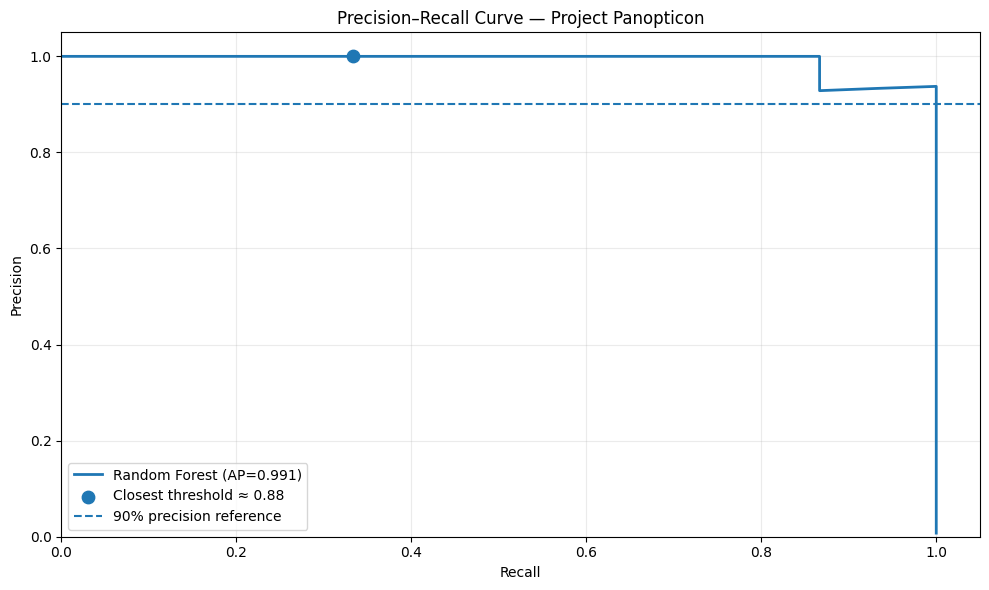

Average Precision (AP): 0.9914
Final probability threshold: 0.90


In [ ]:

# ============================================================
# 6. PRECISION-RECALL CURVE
# ============================================================
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, label=f"Random Forest (AP={average_precision:.3f})")

# The threshold array maps to precision[:-1] / recall[:-1].
if len(thresholds) > 0:
    idx = np.argmin(np.abs(thresholds - STRICT_THRESHOLD))
    plt.scatter(
        recall[idx],
        precision[idx],
        s=80,
        label=f"Closest threshold ≈ {thresholds[idx]:.2f}"
    )

plt.axhline(
    0.90,
    linestyle="--",
    linewidth=1.5,
    label="90% precision reference"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Project Panopticon")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {average_precision:.4f}")
print(f"Final probability threshold: {STRICT_THRESHOLD:.2f}")


Phase 7 — Final Classification Report & Feature Importance

STRICT 90% THRESHOLD — CLASSIFICATION REPORT
              precision    recall  f1-score   support

Not Cheating       0.99      1.00      1.00      1985
    Cheating       1.00      0.27      0.42        15

    accuracy                           0.99      2000
   macro avg       1.00      0.63      0.71      2000
weighted avg       0.99      0.99      0.99      2000



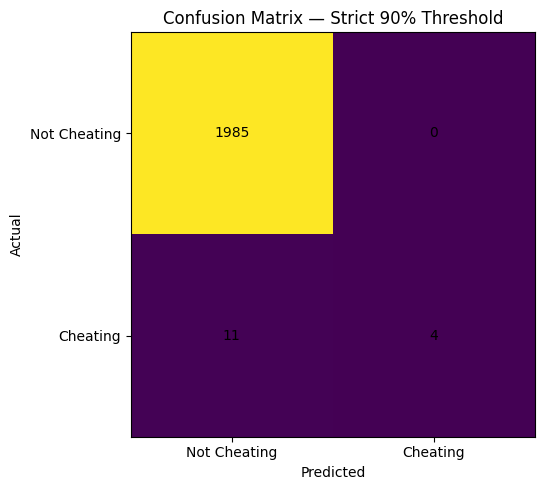

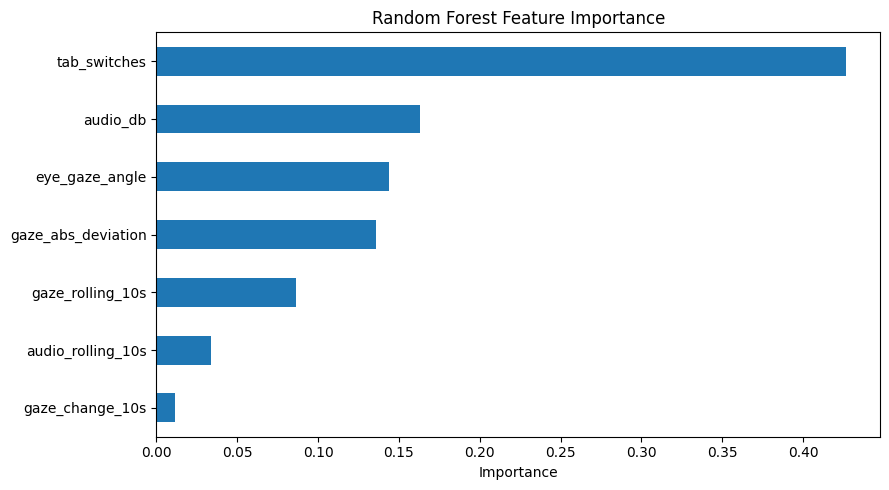


Feature importance:


,importance
tab_switches,0.426210
audio_db,0.162848
eye_gaze_angle,0.143888
gaze_abs_deviation,0.135731
gaze_rolling_10s,0.086260
audio_rolling_10s,0.033565
gaze_change_10s,0.011498


In [ ]:

# ============================================================
# 7. FINAL REPORT
# ============================================================
print("STRICT 90% THRESHOLD — CLASSIFICATION REPORT")
print("=" * 55)
print(
    classification_report(
        y_test,
        y_pred_strict,
        target_names=["Not Cheating", "Cheating"],
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_strict, labels=[0, 1])

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix — Strict 90% Threshold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Not Cheating", "Cheating"])
plt.yticks([0, 1], ["Not Cheating", "Cheating"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nFeature importance:")
display(importance.sort_values(ascending=False).to_frame("importance"))


Phase 8 — Executive Recommendation

In [ ]:

# ============================================================
# 8. AUTOMATIC EXECUTIVE SUMMARY
# ============================================================
fp_default = default_results["FP"]
fp_strict = strict_results["FP"]
precision_strict = strict_results["precision"]
recall_strict = strict_results["recall"]

print("EXECUTIVE SUMMARY")
print("=" * 60)
print(f"Default 0.50 threshold — false positives: {fp_default}")
print(f"Strict  0.90 threshold — false positives: {fp_strict}")
print(f"Strict  0.90 threshold — precision      : {precision_strict:.2%}")
print(f"Strict  0.90 threshold — recall         : {recall_strict:.2%}")

if fp_strict <= fp_default:
    print("\n✅ The strict threshold does not increase false positives on this test split.")
else:
    print("\n⚠️ False positives increased on this test split; review before deployment.")

if precision_strict >= 0.90:
    print("✅ Strict-threshold precision is at least 90% on this held-out test split.")
else:
    print("⚠️ Strict-threshold precision is below 90% on this held-out test split.")

print("\nFinal business rule:")
print("FLAG SUSPICIOUS BEHAVIOR only when predicted cheating probability >= 0.90.")
print("Otherwise, do not automatically accuse the student.")


EXECUTIVE SUMMARY
Default 0.50 threshold — false positives: 0
Strict  0.90 threshold — false positives: 0
Strict  0.90 threshold — precision      : 100.00%
Strict  0.90 threshold — recall         : 26.67%

✅ The strict threshold does not increase false positives on this test split.
✅ Strict-threshold precision is at least 90% on this held-out test split.

Final business rule:
FLAG SUSPICIOUS BEHAVIOR only when predicted cheating probability >= 0.90.
Otherwise, do not automatically accuse the student.
